# Exploratory Data Analysis (EDA) — Rotten Tomatoes Critic Reviews

This notebook performs **pre-cleaning EDA** on the raw Rotten Tomatoes critic reviews dataset.

Main checks included:
- Dataset shape, columns, data types
- Sentiment class distribution: **Fresh vs Rotten**
- Missing values
- Duplicate records and duplicate review texts
- Emoji detection
- Empty / very short reviews
- Review text length analysis
- Date coverage
- Basic categorical overview
- EDA output files for report evidence

In [1]:
# ============================================================
# 1. Imports and Settings
# ============================================================

import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

# Output folder for EDA tables
OUTPUT_DIR = Path("eda_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [2]:
# ============================================================
# 2. Load Raw Dataset
# ============================================================

# Change this path if your CSV is located in another folder
CSV_PATH = "rotten_tomatoes_critic_reviews.csv"

# Fallback path for this generated notebook environment
if not os.path.exists(CSV_PATH):
    CSV_PATH = "/mnt/data/rotten_tomatoes_critic_reviews.csv"

df = pd.read_csv(CSV_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

display(df.head())


Dataset loaded successfully.
Dataset shape: (1130017, 8)


,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content
0,m/0814255,Andrew L. Urban,False,Urban Cinefile,Fresh,NaN,2010-02-06,A fantasy adventure that fuses Greek mythology to contemporary American places and values. Anyone around 15 (give or...
1,m/0814255,Louise Keller,False,Urban Cinefile,Fresh,NaN,2010-02-06,"Uma Thurman as Medusa, the gorgon with a coiffure of writhing snakes and stone-inducing hypnotic gaze is one of the ..."
2,m/0814255,NaN,False,FILMINK (Australia),Fresh,NaN,2010-02-09,"With a top-notch cast and dazzling special effects, this will tide the teens over until the next Harry Potter instal..."
3,m/0814255,Ben McEachen,False,Sunday Mail (Australia),Fresh,3.5/5,2010-02-09,"Whether audiences will get behind The Lightning Thief is hard to predict. Overall, it's an entertaining introduction..."
4,m/0814255,Ethan Alter,True,Hollywood Reporter,Rotten,NaN,2010-02-10,"What's really lacking in The Lightning Thief is a genuine sense of wonder, the same thing that brings viewers back t..."


In [3]:
# ============================================================
# 3. Basic Dataset Structure
# ============================================================

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
display(pd.DataFrame({"columns": df.columns}))

print("\nData types:")
display(df.dtypes.to_frame("data_type"))

print("\nDataset info:")
df.info()


Number of rows: 1130017
Number of columns: 8

Column names:


,columns
0,rotten_tomatoes_link
1,critic_name
2,top_critic
3,publisher_name
4,review_type
5,review_score
6,review_date
7,review_content



Data types:


,data_type
rotten_tomatoes_link,object
critic_name,object
top_critic,bool
publisher_name,object
review_type,object
review_score,object
review_date,object
review_content,object



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1130017 entries, 0 to 1130016
Data columns (total 8 columns):
 #   Column                Non-Null Count    Dtype 
---  ------                --------------    ----- 
 0   rotten_tomatoes_link  1130017 non-null  object
 1   critic_name           1111488 non-null  object
 2   top_critic            1130017 non-null  bool  
 3   publisher_name        1130017 non-null  object
 4   review_type           1130017 non-null  object
 5   review_score          824081 non-null   object
 6   review_date           1130017 non-null  object
 7   review_content        1064211 non-null  object
dtypes: bool(1), object(7)
memory usage: 61.4+ MB


In [4]:
# ============================================================
# 4. Unique Values Overview
# ============================================================

unique_summary = pd.DataFrame({
    "column": df.columns,
    "unique_count": [df[col].nunique(dropna=True) for col in df.columns],
    "missing_count": [df[col].isna().sum() for col in df.columns],
    "missing_percentage": [df[col].isna().mean() * 100 for col in df.columns]
})

unique_summary["missing_percentage"] = unique_summary["missing_percentage"].round(2)

display(unique_summary)
unique_summary.to_csv(OUTPUT_DIR / "unique_values_summary.csv", index=False)


,column,unique_count,missing_count,missing_percentage
0,rotten_tomatoes_link,17712,0,0.00
1,critic_name,11108,18529,1.64
2,top_critic,2,0,0.00
3,publisher_name,2230,0,0.00
4,review_type,2,0,0.00
5,review_score,814,305936,27.07
6,review_date,8015,0,0.00
7,review_content,949181,65806,5.82


## Sentiment Label Distribution

This section checks how many reviews are labelled as **Fresh** and **Rotten** before balancing.


,review_type,count,percentage
0,Fresh,720210,63.73
1,Rotten,409807,36.27


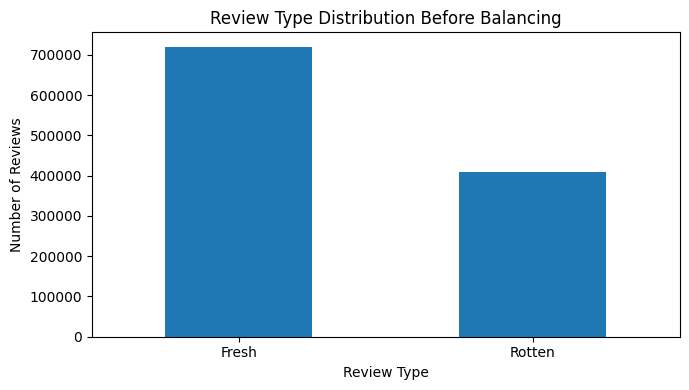

In [5]:
# ============================================================
# 5. Fresh vs Rotten Distribution
# ============================================================

label_col = "review_type"

label_counts = df[label_col].value_counts(dropna=False).reset_index()
label_counts.columns = ["review_type", "count"]
label_counts["percentage"] = (label_counts["count"] / len(df) * 100).round(2)

display(label_counts)
label_counts.to_csv(OUTPUT_DIR / "review_type_distribution.csv", index=False)

# Plot
ax = label_counts.plot(
    x="review_type",
    y="count",
    kind="bar",
    legend=False,
    figsize=(7, 4),
    title="Review Type Distribution Before Balancing"
)

plt.xlabel("Review Type")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [6]:
# ============================================================
# 6. Class Imbalance Ratio
# ============================================================

fresh_count = (df[label_col] == "Fresh").sum()
rotten_count = (df[label_col] == "Rotten").sum()

if min(fresh_count, rotten_count) > 0:
    imbalance_ratio = max(fresh_count, rotten_count) / min(fresh_count, rotten_count)
else:
    imbalance_ratio = np.nan

print(f"Fresh reviews: {fresh_count:,}")
print(f"Rotten reviews: {rotten_count:,}")
print(f"Class imbalance ratio: {imbalance_ratio:.2f}:1")

if fresh_count != rotten_count:
    print("\nThe dataset is imbalanced and should be balanced before model training.")
else:
    print("\nThe dataset is already balanced.")


Fresh reviews: 720,210
Rotten reviews: 409,807
Class imbalance ratio: 1.76:1

The dataset is imbalanced and should be balanced before model training.


## Missing Value Analysis

This section identifies columns with missing values before cleaning.


,column,missing_count,missing_percentage
5,review_score,305936,27.07
7,review_content,65806,5.82
1,critic_name,18529,1.64
0,rotten_tomatoes_link,0,0.00
3,publisher_name,0,0.00
2,top_critic,0,0.00
4,review_type,0,0.00
6,review_date,0,0.00


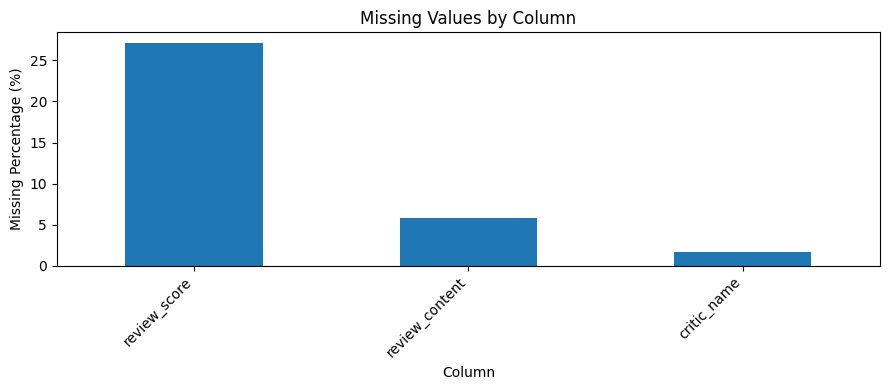

In [7]:
# ============================================================
# 7. Missing Values
# ============================================================

missing_summary = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_percentage": (df.isna().mean().values * 100).round(2)
}).sort_values("missing_count", ascending=False)

display(missing_summary)
missing_summary.to_csv(OUTPUT_DIR / "missing_values_summary.csv", index=False)

# Plot columns with missing values only
missing_plot = missing_summary[missing_summary["missing_count"] > 0]

if len(missing_plot) > 0:
    ax = missing_plot.plot(
        x="column",
        y="missing_percentage",
        kind="bar",
        legend=False,
        figsize=(9, 4),
        title="Missing Values by Column"
    )
    plt.xlabel("Column")
    plt.ylabel("Missing Percentage (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")


In [8]:
# ============================================================
# 8. Rows with Missing Review Content or Missing Labels
# ============================================================

missing_review_content = df["review_content"].isna().sum()
missing_review_type = df["review_type"].isna().sum()

print(f"Rows with missing review content: {missing_review_content:,}")
print(f"Rows with missing review type: {missing_review_type:,}")

display(df[df["review_content"].isna()].head())
display(df[df["review_type"].isna()].head())


Rows with missing review content: 65,806
Rows with missing review type: 0


,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content
80,m/0814255,NaN,False,National Post,Rotten,2.5/4,2010-02-12,NaN
182,m/0878835,NaN,False,National Post,Rotten,2.5/4,2010-04-30,NaN
283,m/0878835,Ben Kenigsberg,True,Time Out,Rotten,2/5,2011-11-17,NaN
293,m/10,Bob Grimm,False,Las Vegas Mercury,Fresh,3/5,2002-07-26,NaN
294,m/10,Philip Martin,False,Arkansas Democrat-Gazette,Fresh,3/5,2002-07-31,NaN


,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content


## Duplicate Analysis

This section checks exact duplicate rows and duplicate review texts.


In [9]:
# ============================================================
# 9. Duplicate Rows and Duplicate Review Content
# ============================================================

exact_duplicate_count = df.duplicated().sum()
duplicate_review_content_count = df["review_content"].duplicated().sum()

print(f"Exact duplicate rows: {exact_duplicate_count:,}")
print(f"Duplicate review_content values: {duplicate_review_content_count:,}")

duplicate_summary = pd.DataFrame({
    "duplicate_type": ["Exact duplicate rows", "Duplicate review_content"],
    "count": [exact_duplicate_count, duplicate_review_content_count],
    "percentage": [
        round(exact_duplicate_count / len(df) * 100, 2),
        round(duplicate_review_content_count / len(df) * 100, 2)
    ]
})

display(duplicate_summary)
duplicate_summary.to_csv(OUTPUT_DIR / "duplicate_summary.csv", index=False)


Exact duplicate rows: 119,471
Duplicate review_content values: 180,835


,duplicate_type,count,percentage
0,Exact duplicate rows,119471,10.57
1,Duplicate review_content,180835,16.00


In [10]:
# Display examples of duplicate review content
duplicate_reviews = df[df["review_content"].duplicated(keep=False)].sort_values("review_content")

print("Example duplicated review contents:")
display(duplicate_reviews[["review_type", "review_content", "critic_name", "publisher_name", "review_date"]].head(10))


Example duplicated review contents:


,review_type,review_content,critic_name,publisher_name,review_date
817657,Fresh,"!), I am overjoyed to report that not only is there much more to this film that just its twist, watching the film wi...",MaryAnn Johanson,Flick Filosopher,2000-01-01
817750,Fresh,"!), I am overjoyed to report that not only is there much more to this film that just its twist, watching the film wi...",MaryAnn Johanson,Flick Filosopher,2000-01-01
828614,Rotten,!@#&*! Sam Arkoff must be screaming 'I told you so' from a !@#&*!mountaintop -- because it took Hollywood 35 !@#&*! ...,Jonathan R. Perry,Tyler Morning Telegraph (Texas),2006-08-20
828620,Rotten,!@#&*! Sam Arkoff must be screaming 'I told you so' from a !@#&*!mountaintop -- because it took Hollywood 35 !@#&*! ...,Jonathan R. Perry,Tyler Morning Telegraph (Texas),2006-08-20
893129,Rotten,""" a jarring combination that goes together as well as peanut butter and poison.""",Kristy Puchko,Pajiba,2017-10-28
893136,Rotten,""" a jarring combination that goes together as well as peanut butter and poison.""",Kristy Puchko,Pajiba,2017-10-28
664150,Fresh,"""'Post Tenebras Lux' works so well because - even at its most random - it always feels like more of a single portrai...",David Ehrlich,Film.com,2013-04-29
664146,Fresh,"""'Post Tenebras Lux' works so well because - even at its most random - it always feels like more of a single portrai...",David Ehrlich,Film.com,2013-04-29
704625,Fresh,"""'Red Army' is a thoughtful and cheer-worthy examination of how sports can shape cultures, redraw borders and change...",Inkoo Kang,TheWrap,2015-01-23
704630,Fresh,"""'Red Army' is a thoughtful and cheer-worthy examination of how sports can shape cultures, redraw borders and change...",Inkoo Kang,TheWrap,2015-01-23


## Text Quality Checks

This section checks empty reviews, very short reviews, review length, and word count.


In [11]:
# ============================================================
# 10. Empty and Very Short Review Content
# ============================================================

text_col = "review_content"

# Convert to string only for EDA text checks
text_series = df[text_col].fillna("").astype(str)

empty_or_whitespace_mask = text_series.str.strip().eq("")
very_short_mask = text_series.str.strip().str.len().between(1, 10)

print(f"Empty or whitespace-only reviews: {empty_or_whitespace_mask.sum():,}")
print(f"Very short reviews, 1-10 characters: {very_short_mask.sum():,}")

print("\nExamples of very short reviews:")
display(df.loc[very_short_mask, ["review_type", "review_content", "critic_name", "publisher_name"]].head(20))


Empty or whitespace-only reviews: 65,806
Very short reviews, 1-10 characters: 1,318

Examples of very short reviews:


,review_type,review_content,critic_name,publisher_name
49,Rotten,Whew boy.,Nick Starkey,Premiere Magazine
567,Fresh,Great fun.,Geoff Brown,Time Out
949,Rotten,Redundant.,John Beifuss,"Commercial Appeal (Memphis, TN)"
1016,Fresh,Absorbing.,Terry Lawson,Detroit Free Press
2550,Rotten,Boring!!!,Eric Lurio,Greenwich Village Gazette
3909,Fresh,Diverting.,Lou Lumenick,New York Post
4200,Fresh,engaging,Blake French,Filmcritic.com
4231,Rotten,Why?,Christopher Smith,Bangor Daily News (Maine)
6033,Rotten,Just ugh.,Travis Nichols,Seattle Post-Intelligencer
6308,Fresh,Great.,Sabadino Parker,PopMatters


,char_count,word_count
count,1130017.00,1130017.00
mean,120.55,20.09
std,61.63,10.46
min,0.00,0.00
25%,77.00,13.00
50%,122.00,20.00
75%,164.00,27.00
max,258.00,55.00


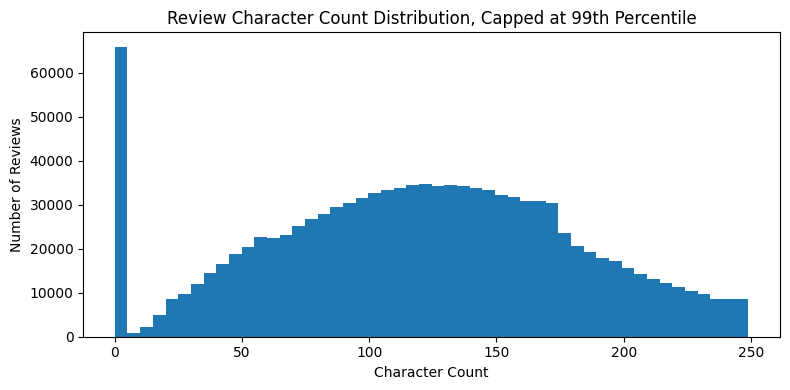

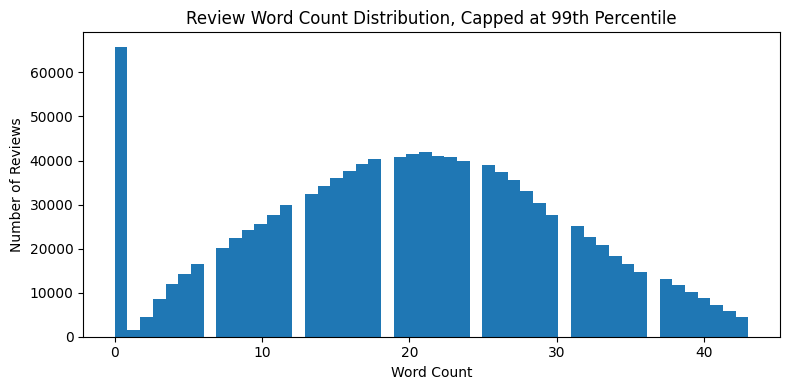

In [12]:
# ============================================================
# 11. Review Length Analysis
# ============================================================

df["char_count"] = text_series.str.len()
df["word_count"] = text_series.str.split().str.len()

length_summary = df[["char_count", "word_count"]].describe().round(2)
display(length_summary)
length_summary.to_csv(OUTPUT_DIR / "review_length_summary.csv")

# Plot character count distribution using a capped range for readability
char_cap = df["char_count"].quantile(0.99)

plt.figure(figsize=(8, 4))
plt.hist(df.loc[df["char_count"] <= char_cap, "char_count"], bins=50)
plt.title("Review Character Count Distribution, Capped at 99th Percentile")
plt.xlabel("Character Count")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

# Plot word count distribution using a capped range for readability
word_cap = df["word_count"].quantile(0.99)

plt.figure(figsize=(8, 4))
plt.hist(df.loc[df["word_count"] <= word_cap, "word_count"], bins=50)
plt.title("Review Word Count Distribution, Capped at 99th Percentile")
plt.xlabel("Word Count")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()


char_count                                word_count         \
                 count    mean median    std min  max      count   mean   
review_type                                                               
Fresh           720210  122.59  124.0  61.56   0  257     720210  20.36   
Rotten          409807  116.97  118.0  61.57   0  258     409807  19.62   

                                   
            median    std min max  
review_type                        
Fresh         21.0  10.45   0  55  
Rotten        20.0  10.48   0  54

<Figure size 700x400 with 0 Axes>

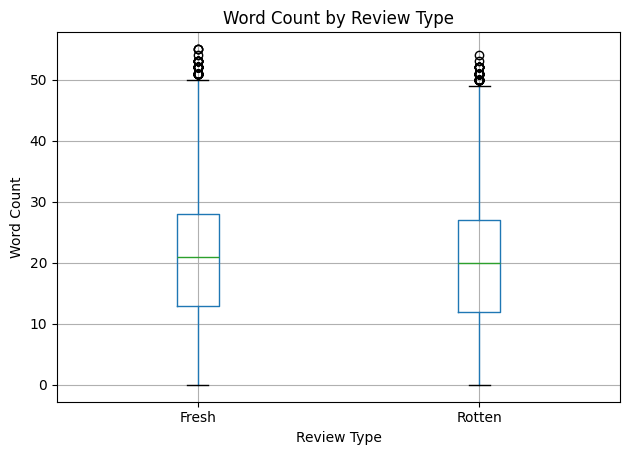

In [13]:
# ============================================================
# 12. Text Length by Sentiment Class
# ============================================================

length_by_class = df.groupby("review_type")[["char_count", "word_count"]].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

display(length_by_class)
length_by_class.to_csv(OUTPUT_DIR / "review_length_by_class.csv")

# Boxplot for word count by review type
valid_labels = df[df["review_type"].isin(["Fresh", "Rotten"])]

plt.figure(figsize=(7, 4))
valid_labels.boxplot(column="word_count", by="review_type")
plt.title("Word Count by Review Type")
plt.suptitle("")
plt.xlabel("Review Type")
plt.ylabel("Word Count")
plt.tight_layout()
plt.show()


## Emoji Check

This section detects rows that contain emoji characters in `review_content`.


In [14]:
# ============================================================
# 13. Emoji Detection
# ============================================================

# Covers common emoji Unicode ranges, including emoticons, pictographs, symbols, flags, and dingbats.
emoji_pattern = re.compile(
    "["
    "\U0001F1E6-\U0001F1FF"  # flags
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F680-\U0001F6FF"  # transport & map
    "\U0001F700-\U0001F77F"  # alchemical symbols
    "\U0001F780-\U0001F7FF"  # geometric shapes extended
    "\U0001F800-\U0001F8FF"  # supplemental arrows-c
    "\U0001F900-\U0001F9FF"  # supplemental symbols & pictographs
    "\U0001FA00-\U0001FAFF"  # symbols & pictographs extended-a
    "\U00002700-\U000027BF"  # dingbats
    "\U00002600-\U000026FF"  # miscellaneous symbols
    "]+",
    flags=re.UNICODE
)

def contains_emoji(text):
    return bool(emoji_pattern.search(str(text)))

def extract_emojis(text):
    return "".join(emoji_pattern.findall(str(text)))

emoji_mask = text_series.apply(contains_emoji)
emoji_rows = df.loc[emoji_mask, ["review_type", "review_content", "critic_name", "publisher_name", "review_date"]].copy()
emoji_rows["emojis_found"] = emoji_rows["review_content"].apply(extract_emojis)

emoji_count = int(emoji_mask.sum())
emoji_percentage = round(emoji_count / len(df) * 100, 4)

print(f"Rows containing emoji: {emoji_count:,}")
print(f"Percentage of dataset containing emoji: {emoji_percentage}%")

display(emoji_rows.head(30))

emoji_rows.to_csv(OUTPUT_DIR / "emoji_rows.csv", index=False)


Rows containing emoji: 5
Percentage of dataset containing emoji: 0.0004%


,review_type,review_content,critic_name,publisher_name,review_date,emojis_found
437171,Fresh,"Even though I ♥ Huckabees might have more on its mind than any American film this year, the entire time I watched it...",Jeremy Heilman,MovieMartyr.com,2004-10-06,♥
437296,Fresh,"I ♥ Huckabees might be too smart for its own good, but that also seems to be the point. Russell extols liberal activ...",Mark Pfeiffer,Reel Times: Reflections on Cinema,2005-04-14,♥
437309,Fresh,I ♥ Huckabees is a rarity-a tremendously optimistic film for a truly dark time.,Gavin Smith,Film Comment Magazine,2013-11-19,♥
948949,Rotten,The Emoji Movie shows how low Hollywood will sink for easy 💰.,Jordan Hoffman,New York Daily News,2017-07-27,💰
1066324,Fresh,★★★★★ Babak Anvari's Under the Shadow uses the haunted house set-up and classical filmmaking techniques expressly fo...,Martyn Conterio,CineVue,2016-08-31,★★★★★


In [15]:
# ============================================================
# 14. Emoji Counts by Review Type
# ============================================================

emoji_by_class = df.assign(has_emoji=emoji_mask).groupby("review_type")["has_emoji"].agg(["sum", "count"])
emoji_by_class["percentage"] = (emoji_by_class["sum"] / emoji_by_class["count"] * 100).round(4)
emoji_by_class = emoji_by_class.rename(columns={"sum": "emoji_rows", "count": "total_rows"})

display(emoji_by_class)
emoji_by_class.to_csv(OUTPUT_DIR / "emoji_by_review_type.csv")


,emoji_rows,total_rows,percentage
review_type,,,
Fresh,4,720210,0.0006
Rotten,1,409807,0.0002


## Date and Time Coverage

This section checks the review date range and yearly review distribution.


Invalid or missing review dates: 0
Earliest review date: 1800-01-01 00:00:00
Latest review date: 2020-10-29 00:00:00


,year,count
0,1800,83
1,1923,1
2,1927,3
3,1928,1
4,1929,1


,year,count
85,2016,57886
86,2017,60575
87,2018,76313
88,2019,81911
89,2020,45746


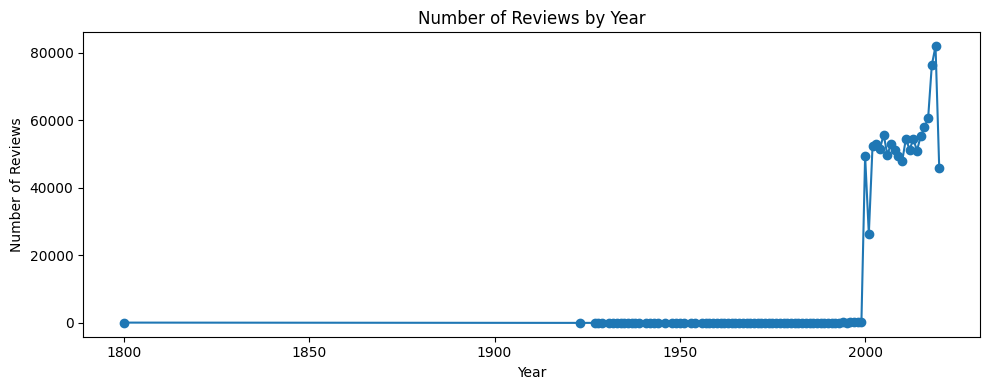

In [16]:
# ============================================================
# 15. Review Date Coverage
# ============================================================

df["review_date_parsed"] = pd.to_datetime(df["review_date"], errors="coerce")

invalid_dates = df["review_date_parsed"].isna().sum()
min_date = df["review_date_parsed"].min()
max_date = df["review_date_parsed"].max()

print(f"Invalid or missing review dates: {invalid_dates:,}")
print(f"Earliest review date: {min_date}")
print(f"Latest review date: {max_date}")

df["review_year"] = df["review_date_parsed"].dt.year

year_counts = df["review_year"].value_counts().sort_index().reset_index()
year_counts.columns = ["year", "count"]

display(year_counts.head())
display(year_counts.tail())

year_counts.to_csv(OUTPUT_DIR / "review_count_by_year.csv", index=False)

plt.figure(figsize=(10, 4))
plt.plot(year_counts["year"], year_counts["count"], marker="o")
plt.title("Number of Reviews by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()


review_type,Fresh,Rotten
review_year,,
2011,34651,19864
2012,33129,18150
2013,35134,19229
2014,32928,18100
2015,36825,18460
2016,39064,18822
2017,41275,19300
2018,53455,22858
2019,57781,24130


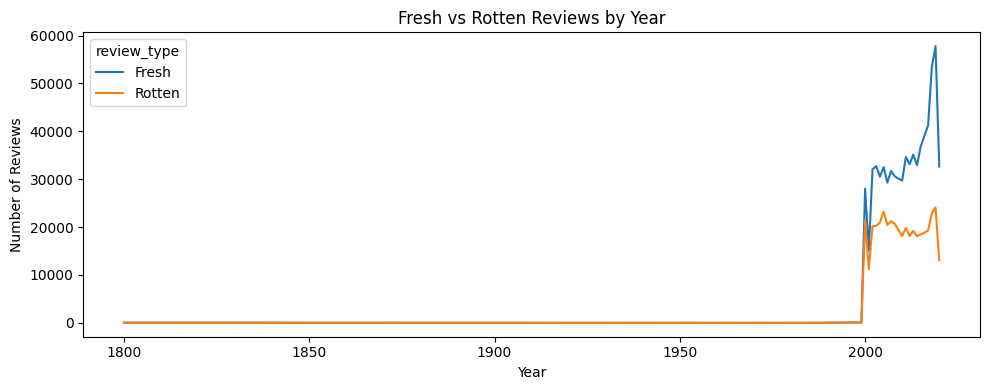

In [17]:
# ============================================================
# 16. Review Type by Year
# ============================================================

year_class_counts = (
    df[df["review_type"].isin(["Fresh", "Rotten"])]
    .groupby(["review_year", "review_type"])
    .size()
    .unstack(fill_value=0)
)

display(year_class_counts.tail(10))
year_class_counts.to_csv(OUTPUT_DIR / "review_type_by_year.csv")

year_class_counts.plot(figsize=(10, 4), title="Fresh vs Rotten Reviews by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()


## Categorical Feature Overview

This section gives a quick overview of critic, publisher, top critic, and score-related fields.


In [18]:
# ============================================================
# 17. Top Critics, Publishers, and Top-Critic Flag
# ============================================================

def value_counts_table(series, name, top_n=10):
    table = series.value_counts(dropna=False).head(top_n).reset_index()
    table.columns = [name, "count"]
    return table

print("Top critic flag distribution:")
display(value_counts_table(df["top_critic"], "top_critic", top_n=10))

print("\nTop 10 publishers:")
display(value_counts_table(df["publisher_name"], "publisher_name", top_n=10))

print("\nTop 10 critics:")
display(value_counts_table(df["critic_name"], "critic_name", top_n=10))


Top critic flag distribution:


,top_critic,count
0,False,841481
1,True,288536



Top 10 publishers:


,publisher_name,count
0,New York Times,13293
1,Variety,11620
2,Time Out,11313
3,eFilmCritic.com,10307
4,Los Angeles Times,10084
5,Washington Post,9074
6,Hollywood Reporter,9009
7,Slant Magazine,8976
8,Entertainment Weekly,8649
9,Austin Chronicle,8219



Top 10 critics:


,critic_name,count
0,NaN,18529
1,Emanuel Levy,8173
2,Dennis Schwartz,6526
3,Roger Ebert,6417
4,Brian Orndorf,6082
5,Frank Swietek,6038
6,Jeffrey M. Anderson,5821
7,Roger Moore,5634
8,David Nusair,5264
9,James Berardinelli,5253


In [19]:
# ============================================================
# 18. Review Score Overview
# ============================================================

score_missing = df["review_score"].isna().sum()
score_available = df["review_score"].notna().sum()

print(f"Rows with review score: {score_available:,}")
print(f"Rows missing review score: {score_missing:,}")
print(f"Review score missing percentage: {score_missing / len(df) * 100:.2f}%")

print("\nMost common review_score values:")
score_table = df["review_score"].value_counts(dropna=False).head(20).reset_index()
score_table.columns = ["review_score", "count"]
display(score_table)


Rows with review score: 824,081
Rows missing review score: 305,936
Review score missing percentage: 27.07%

Most common review_score values:


,review_score,count
0,NaN,305936
1,3/5,90273
2,4/5,83659
3,3/4,72366
4,2/5,60174
5,2/4,47546
6,2.5/4,44994
7,3.5/4,34371
8,3.5/5,30885
9,B,24358


## Basic Word Frequency Check

This section gives a light pre-cleaning word frequency overview.  
It is not final NLP preprocessing; it is only to understand the raw text.


,word,frequency
0,film,15470
1,movie,11596
2,one,8085
3,more,7071
4,all,6913
5,about,6495
6,like,6475
7,than,6308
8,there,5275
9,story,5236


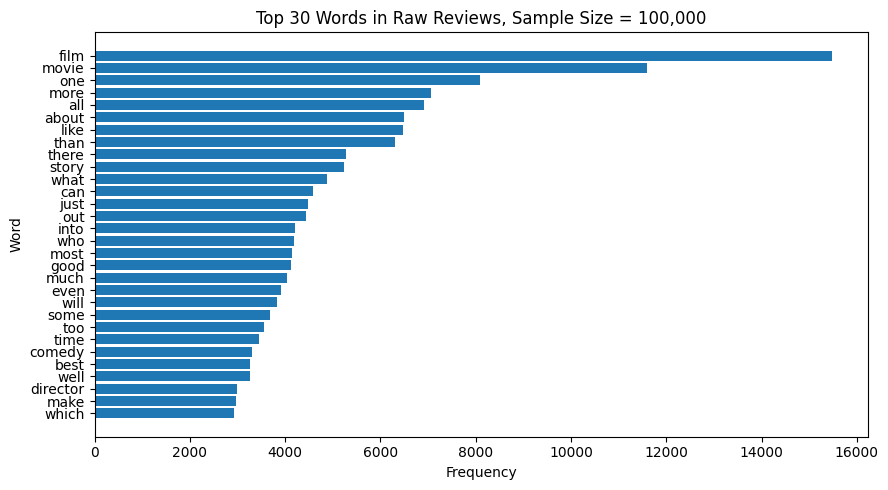

In [20]:
# ============================================================
# 19. Simple Word Frequency Before Cleaning
# ============================================================

from collections import Counter

# Use a sample if the dataset is very large to keep this step fast
sample_size = min(100000, len(df))
sample_text = text_series.sample(sample_size, random_state=42)

basic_stopwords = {
    "the", "a", "an", "and", "or", "but", "is", "are", "was", "were",
    "to", "of", "in", "on", "for", "with", "as", "by", "it", "this",
    "that", "its", "be", "from", "at", "his", "her", "their", "has",
    "have", "had", "not", "you", "he", "she", "they", "we", "i"
}

tokens = []
for text in sample_text:
    words = re.findall(r"\b[a-zA-Z]{3,}\b", text.lower())
    tokens.extend([w for w in words if w not in basic_stopwords])

word_freq = pd.DataFrame(Counter(tokens).most_common(30), columns=["word", "frequency"])

display(word_freq)
word_freq.to_csv(OUTPUT_DIR / "top_words_raw_sample.csv", index=False)

plt.figure(figsize=(9, 5))
plt.barh(word_freq["word"][::-1], word_freq["frequency"][::-1])
plt.title(f"Top 30 Words in Raw Reviews, Sample Size = {sample_size:,}")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()


## EDA Summary for Report

This section automatically creates a short summary table that can be used as evidence for the methodology/report.


In [21]:
# ============================================================
# 20. Final EDA Summary Table
# ============================================================

eda_summary = pd.DataFrame({
    "EDA Item": [
        "Total rows",
        "Total columns",
        "Fresh reviews",
        "Rotten reviews",
        "Class imbalance ratio",
        "Rows with missing review_content",
        "Rows with missing review_type",
        "Exact duplicate rows",
        "Duplicate review_content values",
        "Empty or whitespace-only reviews",
        "Very short reviews, 1-10 characters",
        "Rows containing emoji",
        "Earliest review date",
        "Latest review date"
    ],
    "Value": [
        f"{len(df):,}",
        f"{df.shape[1]:,}",
        f"{fresh_count:,}",
        f"{rotten_count:,}",
        f"{imbalance_ratio:.2f}:1",
        f"{missing_review_content:,}",
        f"{missing_review_type:,}",
        f"{exact_duplicate_count:,}",
        f"{duplicate_review_content_count:,}",
        f"{empty_or_whitespace_mask.sum():,}",
        f"{very_short_mask.sum():,}",
        f"{emoji_count:,}",
        str(min_date.date()) if pd.notna(min_date) else "Not available",
        str(max_date.date()) if pd.notna(max_date) else "Not available"
    ]
})

display(eda_summary)
eda_summary.to_csv(OUTPUT_DIR / "final_eda_summary.csv", index=False)

print("EDA completed. Output CSV files saved in:", OUTPUT_DIR.resolve())


,EDA Item,Value
0,Total rows,"1,130,017"
1,Total columns,12
2,Fresh reviews,"720,210"
3,Rotten reviews,"409,807"
4,Class imbalance ratio,1.76:1
5,Rows with missing review_content,"65,806"
6,Rows with missing review_type,0
7,Exact duplicate rows,"119,471"
8,Duplicate review_content values,"180,835"
9,Empty or whitespace-only reviews,"65,806"


EDA completed. Output CSV files saved in: C:\Users\ASUS\Desktop\Afiq\Study\SMC\Assignment\eda_outputs


## Suggested Cleaning Decisions Based on EDA

Use the results above to justify cleaning decisions in the report:

1. Remove rows with missing `review_content` or missing `review_type`.
2. Keep only the required sentiment labels: `Fresh` and `Rotten`.
3. Remove or handle duplicate review texts if they may bias the model.
4. Remove emoji rows if the count is very small, or normalize emojis if they are frequent.
5. Apply text preprocessing for traditional ML models.
6. Preserve raw text structure for transformer models such as BERT.
7. Apply 50/50 class balancing before model training to avoid biased prediction.
